In [101]:
import pandas as pd

# Dane treningowe

In [102]:
pizza = pd.read_csv('pizza.csv')
pizza.head()

,company,price_cad,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
0,A,$18,16 inch,smoked_beef,american_favorite,jumbo,no,yes,yes
1,B,$12,12 inch,chicken,classic,medium,yes,no,no
2,B,$12,12 inch,smoked_beef,crunchy,medium,no,yes,no
3,E,$12,12 inch,smoked_beef,crunchy,medium,no,yes,no
4,B,$15,12 inch,mushrooms,crunchy,medium,no,yes,yes


In [103]:
pizza.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   company          108 non-null    object
 1   price_cad        108 non-null    object
 2   diameter         108 non-null    object
 3   topping          108 non-null    object
 4   variant          108 non-null    object
 5   size             108 non-null    object
 6   extra_sauce      108 non-null    object
 7   extra_cheese     108 non-null    object
 8   extra_mushrooms  108 non-null    object
dtypes: object(9)
memory usage: 7.7+ KB


In [104]:
pizza['size'].unique()

array(['jumbo', 'medium', 'XL', 'large', 'small', 'reguler'], dtype=object)

In [105]:
pizza = pd.get_dummies(pizza, columns=['company'], prefix= 'Company', prefix_sep='_', dtype=int)
pizza['price_cad'] = pizza['price_cad'].replace({'\$': ''}, regex=True).astype(float)
pizza['diameter'] = pizza['diameter'].replace({'inch': ''}, regex=True).astype(float)
pizza = pd.get_dummies(pizza, columns=['topping'], prefix= 'Topping', prefix_sep='_', dtype=int)
pizza = pd.get_dummies(pizza, columns=['variant'], prefix= 'Variant', prefix_sep='_', dtype=int)
pizza['size'] = pizza['size'].map({'small': 0, 'medium': 1, 'reguler': 2, 'large': 3, 'XL': 4, 'jumbo': 5})
pizza['extra_sauce'] = pizza['extra_sauce'].map({'no': 0, 'yes': 1})
pizza['extra_cheese'] = pizza['extra_cheese'].map({'no': 0, 'yes': 1})
pizza['extra_mushrooms'] = pizza['extra_mushrooms'].map({'no': 0, 'yes': 1})
pizza = pizza.dropna(how = "any")
pizza

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/var/folders/kz/c5mzvp0d4b358tc1zs42zpgm0000gn/T/ipykernel_17261/387338857.py:2: SyntaxWarning: invalid escape sequence '\$'
  pizza['price_cad'] = pizza['price_cad'].replace({'\$': ''}, regex=True).astype(float)


,price_cad,diameter,size,extra_sauce,extra_cheese,extra_mushrooms,Company_A,Company_B,Company_C,Company_D,...,Variant_gournet_greek,Variant_italian_veggie,Variant_meat_eater,Variant_meat_lovers,Variant_neptune_tuna,Variant_new_york,Variant_spicy tuna,Variant_spicy_tuna,Variant_super_supreme,Variant_thai_veggie
0,18.0,16.0,5,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,12.0,12.0,1,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,12.0,12.0,1,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,12.0,12.0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,15.0,12.0,1,0,1,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,17.0,14.0,3,1,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
104,14.0,12.0,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
105,14.0,12.0,1,0,1,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
106,16.0,14.0,3,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


# Dane testowe

In [106]:
pizza_test = pd.read_csv('pizza_test.csv')
pizza_test.head()

,company,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
0,A,18.5 inch,mozzarella,super_supreme,jumbo,no,no,no
1,A,14 inch,smoked_beef,double_signature,reguler,yes,no,yes
2,E,12 inch,chicken,double_decker,medium,no,yes,no
3,E,12 inch,mozzarella,classic,medium,yes,yes,yes
4,E,8.5 inch,mozzarella,classic,small,yes,no,yes


In [107]:
pizza_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   company          21 non-null     object
 1   diameter         21 non-null     object
 2   topping          21 non-null     object
 3   variant          21 non-null     object
 4   size             21 non-null     object
 5   extra_sauce      21 non-null     object
 6   extra_cheese     21 non-null     object
 7   extra_mushrooms  21 non-null     object
dtypes: object(8)
memory usage: 1.4+ KB


In [108]:
pizza_test = pd.get_dummies(pizza_test, columns=['company'], prefix= 'Company', prefix_sep='_', dtype=int)
pizza_test['diameter'] = pizza_test['diameter'].replace({'inch': ''}, regex=True).astype(float)
pizza_test = pd.get_dummies(pizza_test, columns=['topping'], prefix= 'Topping', prefix_sep='_', dtype=int)
pizza_test = pd.get_dummies(pizza_test, columns=['variant'], prefix= 'Variant', prefix_sep='_', dtype=int)
pizza_test['size'] = pizza_test['size'].map({'small': 0, 'medium': 1, 'reguler': 2, 'large': 3, 'XL': 4, 'jumbo': 5})
pizza_test['extra_sauce'] = pizza_test['extra_sauce'].map({'no': 0, 'yes': 1})
pizza_test['extra_cheese'] = pizza_test['extra_cheese'].map({'no': 0, 'yes': 1})
pizza_test['extra_mushrooms'] = pizza_test['extra_mushrooms'].map({'no': 0, 'yes': 1})
pizza_test = pizza_test.dropna(how = "any")
pizza_test.head()

,diameter,size,extra_sauce,extra_cheese,extra_mushrooms,Company_A,Company_B,Company_C,Company_D,Company_E,...,Variant_crunchy,Variant_double_decker,Variant_double_mix,Variant_double_signature,Variant_extravaganza,Variant_gournet_greek,Variant_meat_lovers,Variant_new_york,Variant_spicy_tuna,Variant_super_supreme
0,18.5,5,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,14.0,2,1,0,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,12.0,1,0,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
3,12.0,1,1,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,8.5,0,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


# Regresja

In [109]:
X = pizza.drop('price_cad', axis=1)
y = pizza['price_cad']

In [110]:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['squared_error', 'friedman_mse']
}

In [111]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

rgtree = DecisionTreeRegressor(random_state=42)
grid_search = GridSearchCV(rgtree, param_grid, cv=5, scoring='r2')
grid_search.fit(X, y)

,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'criterion': ['squared_error', 'friedman_mse'], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [112]:
grid_search.best_params_

{'criterion': 'squared_error', 'max_depth': 10, 'min_samples_split': 2}

In [113]:
grid_search.best_score_

np.float64(0.8879778970290026)

In [114]:
best_pizza_model = grid_search.best_estimator_

In [115]:
X_test = pizza_test.reindex(columns = X.columns, fill_value=0)
y_pred = best_pizza_model.predict(X_test)
y_pred = pd.Series(y_pred, name='price_cad')
y_pred.to_csv('p.csv', index=False)

# Wizualizacja


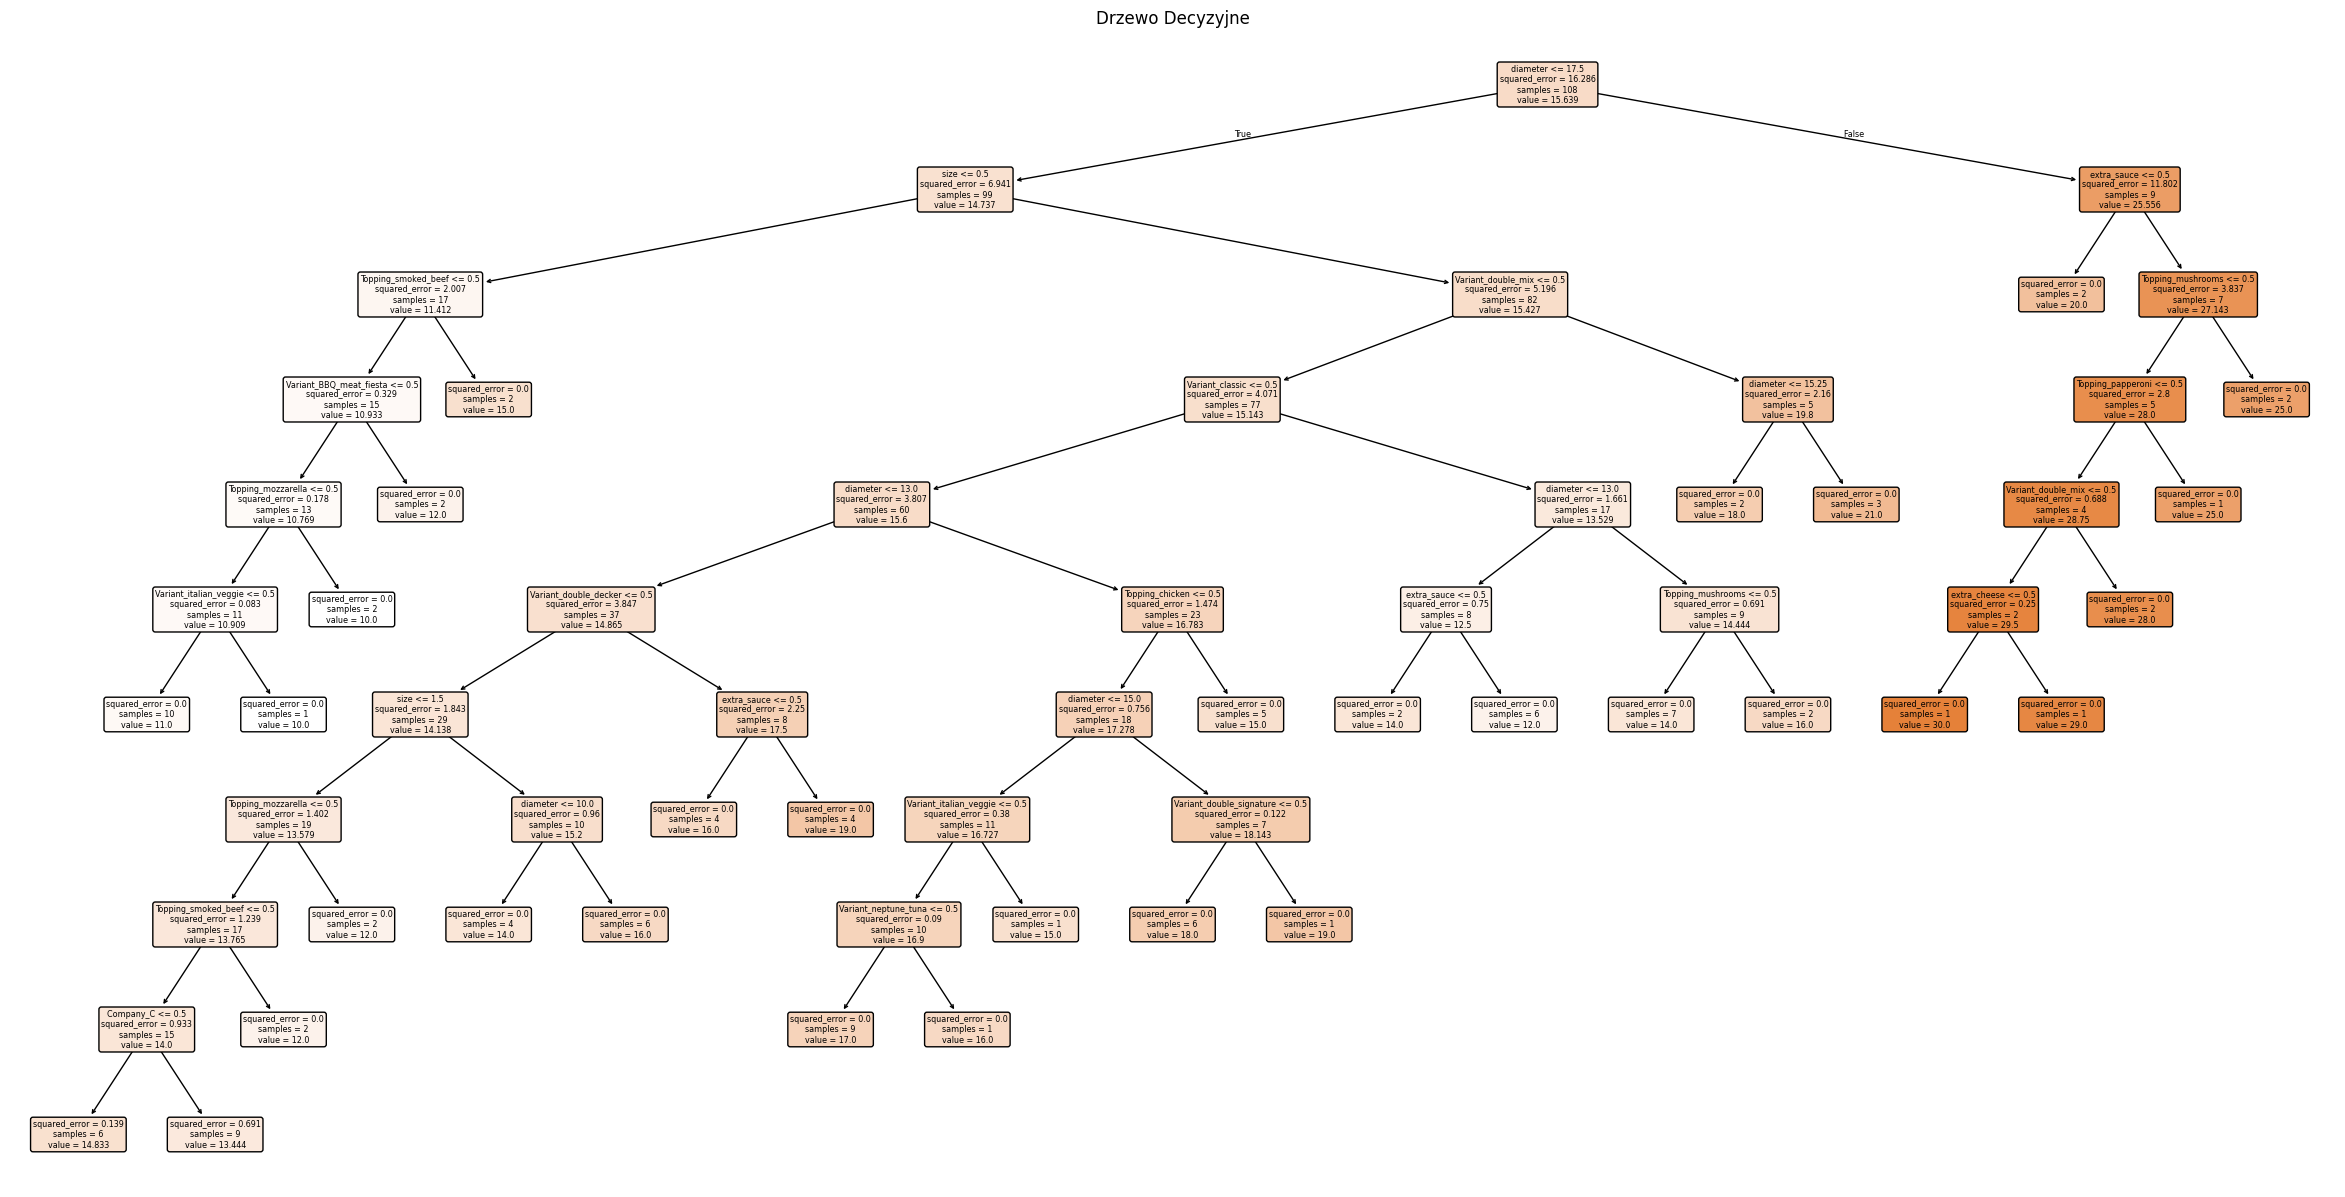

In [116]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 15))
plot_tree(best_pizza_model, feature_names=X.columns, filled=True, rounded=True)
plt.title("Drzewo Decyzyjne")
plt.show()

/var/folders/kz/c5mzvp0d4b358tc1zs42zpgm0000gn/T/ipykernel_17261/158585802.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances.values, y=feat_importances.index, palette="flare")


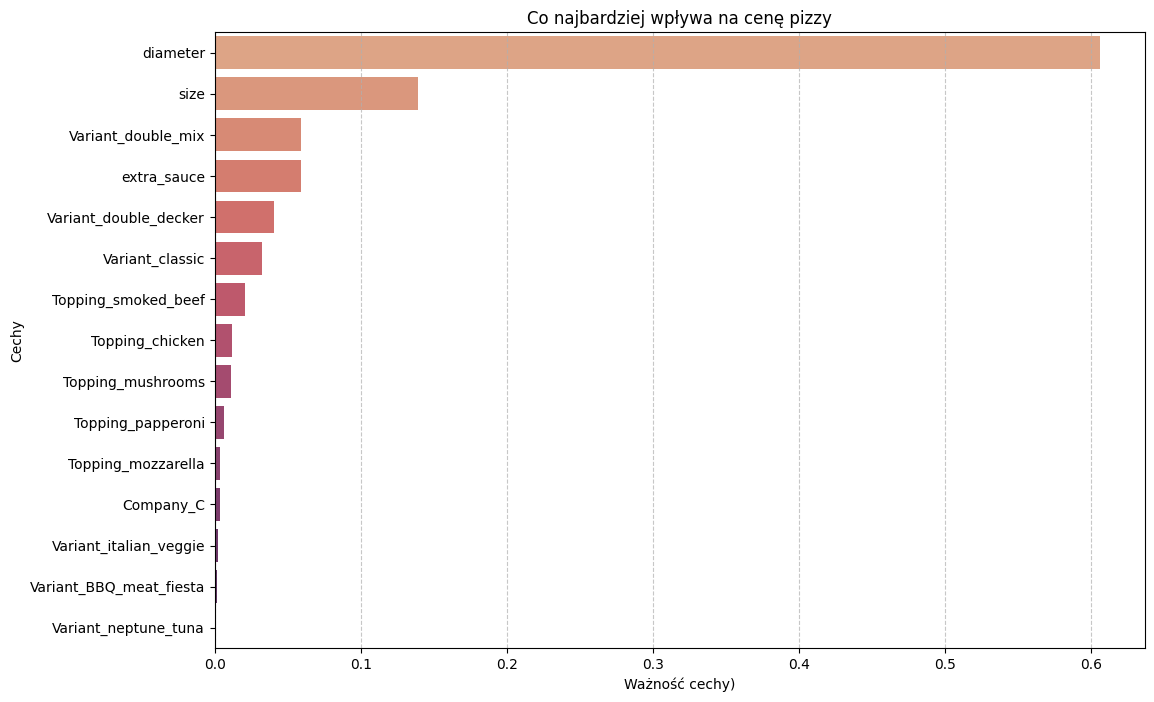

In [117]:
import seaborn as sns

importances = best_pizza_model.feature_importances_
feature_names = X.columns
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=feat_importances.values, y=feat_importances.index, palette="flare")
plt.title("Co najbardziej wpływa na cenę pizzy")
plt.xlabel("Ważność cechy)")
plt.ylabel("Cechy")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()